In [ ]:
# Run the repository tests without allowing one missing optional fixture to hide the exit code.
import subprocess, sys, os

test_files = list((REPO_DIR / "tests").glob("test_*.py"))
if test_files:
    result = subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=REPO_DIR)
    print("pytest return code:", result.returncode)
else:
    print("No test_*.py files were found in the cloned repository.")
    print("The additional contract tests below still exercise the implemented interfaces.")


pytest return code: 0


In [ ]:
# Additional local contract checks against PyTorch reference computations.
import math, numpy as np, torch

from student.modules import (
    Linear, Embedding, RMSNorm, silu, SwiGLU, RotaryPositionalEmbedding,
    softmax, scaled_dot_product_attention, CausalMultiHeadSelfAttention,
    TransformerBlock,
)
from student.transformer_lm import TransformerLM
from student.losses import cross_entropy
from student.optimizer import AdamW, get_lr_cosine_schedule
from student.clipping import gradient_clipping
from student.data import get_batch
from student.generation import generate, _apply_top_p

torch.manual_seed(0)
np.random.seed(0)

def assert_close(a, b, atol=1e-5, rtol=1e-5):
    torch.testing.assert_close(a, b, atol=atol, rtol=rtol)

# Linear
w = torch.randn(5, 3); x = torch.randn(2, 7, 3)
m = Linear(3, 5); m.W.data.copy_(w)
assert_close(m(x), x @ w.T)

# Embedding
ew = torch.randn(11, 4); ids = torch.tensor([[1,5,2],[0,10,3]])
em = Embedding(11,4); em.weight.data.copy_(ew)
assert_close(em(ids), ew[ids])

# RMSNorm
rx = torch.randn(2, 3, 8)
rm = RMSNorm(8)
expected_r = rx / torch.sqrt(rx.pow(2).mean(-1, keepdim=True) + 1e-5) * rm.weight
assert_close(rm(rx), expected_r)

# SiLU / SwiGLU
sx = torch.randn(2,4,6)
assert_close(silu(sx), sx * torch.sigmoid(sx))

# RoPE
pos = torch.arange(5).expand(2,5)
qx = torch.randn(2,5,8)
rope = RotaryPositionalEmbedding(10000.0, 8, 16)
inv = 10000.0 ** (-torch.arange(0,8,2,dtype=torch.float32)/8)
angles = pos.float()[...,None] * inv
xe, xo = qx[...,::2], qx[...,1::2]
rope_ref = torch.stack(
    (xe*torch.cos(angles)-xo*torch.sin(angles),
     xe*torch.sin(angles)+xo*torch.cos(angles)), -1).flatten(-2)
assert_close(rope(qx,pos), rope_ref)

# Stable softmax
big = torch.tensor([[10000.,10001.],[1.,-1.]])
assert_close(softmax(big,-1), torch.softmax(big,-1))

# SDPA, including a boolean mask
Q = torch.randn(2,3,5,4); K = torch.randn(2,3,6,4); V = torch.randn(2,3,6,7)
mask = torch.rand(5,6) > 0.3
got = scaled_dot_product_attention(Q,K,V,mask)
scores = Q @ K.transpose(-1,-2) / math.sqrt(4)
scores = scores.masked_fill(~mask, float("-inf"))
assert_close(got, torch.softmax(scores,-1) @ V)

# Causal MHA with RoPE
mha = CausalMultiHeadSelfAttention(16,4,8,10000.0)
xx = torch.randn(1,6,16)
yy = mha(xx)
xx2 = xx.clone(); xx2[:,4:] = torch.randn_like(xx2[:,4:])
yy2 = mha(xx2)
assert yy.shape == xx.shape
assert_close(yy[:,:4], yy2[:,:4], atol=2e-5, rtol=2e-5)

# Block / LM
block = TransformerBlock(16,4,32,max_seq_len=8)
assert block(torch.randn(2,8,16)).shape == (2,8,16)
lm = TransformerLM(20,8,2,16,4,32)
lm_out = lm(torch.randint(0,20,(2,8)))
assert lm_out.shape == (2,8,20)

# Cross entropy
logits = torch.randn(2,3,17)
targets = torch.randint(0,17,(2,3))
assert_close(
    cross_entropy(logits, targets),
    torch.nn.functional.cross_entropy(logits.reshape(-1,17), targets.reshape(-1)),
    atol=1e-6, rtol=1e-6,
)

# AdamW vs PyTorch AdamW
p_ref = torch.nn.Parameter(torch.randn(6,4))
p_new = torch.nn.Parameter(p_ref.detach().clone())
opt_ref = torch.optim.AdamW([p_ref], lr=1e-3, betas=(0.9,0.999), eps=1e-8, weight_decay=0.1)
opt_new = AdamW([p_new], lr=1e-3, betas=(0.9,0.999), eps=1e-8, weight_decay=0.1)
for _ in range(3):
    g = torch.randn_like(p_ref)
    p_ref.grad = g.clone(); p_new.grad = g.clone()
    opt_ref.step(); opt_new.step()
assert_close(p_ref, p_new, atol=2e-6, rtol=2e-6)

# LR schedule
assert get_lr_cosine_schedule(0,1.0,0.1,10,20) == 0.0
assert abs(get_lr_cosine_schedule(10,1.0,0.1,10,20)-1.0) < 1e-9
assert abs(get_lr_cosine_schedule(20,1.0,0.1,10,20)-0.1) < 1e-9
assert abs(get_lr_cosine_schedule(30,1.0,0.1,10,20)-0.1) < 1e-9

# Gradient clipping
ps = [torch.nn.Parameter(torch.tensor([3.,4.])), torch.nn.Parameter(torch.tensor([0.]))]
ps[0].grad = torch.tensor([3.,4.]); ps[1].grad = torch.tensor([12.])
gradient_clipping(ps, 5.0)
norm = math.sqrt(sum(float((p.grad**2).sum()) for p in ps))
assert norm < 5.0

# Data loading
arr = np.arange(100, dtype=np.int64)
a,b = get_batch(arr,7,9,"cpu")
assert a.shape == b.shape == (7,9)
assert torch.all(b == a+1)

# Top-p boundary and generation
probs = torch.tensor([[0.50,0.30,0.15,0.05]])
filtered = _apply_top_p(probs,0.8)
assert torch.allclose(filtered, torch.tensor([[0.625,0.375,0.,0.]]))

class Toy(torch.nn.Module):
    context_length = 5
    def forward(self, ids):
        out = torch.zeros(ids.shape[0], ids.shape[1], 10)
        out[...,2] = 1.0
        return out

generated = generate(Toy(), torch.tensor([1,2]), 3)
assert generated.shape == (5,)

print("All additional contract checks passed.")


All additional contract checks passed.


## 3. TinyStories training run

In [ ]:
# 3. TinyStories data: memory-mapped validation split + vocabulary
from pathlib import Path
import numpy as np

data_dir = REPO_DIR / "data"
bin_path = data_dir / "tinystories_valid.bin"
meta_path = data_dir / "tinystories_valid.meta" # Corrected from tinystories_valid.bin.meta
vocab_path = data_dir / "tinystories_vocab_merges.pt"

required = [bin_path, meta_path, vocab_path, REPO_DIR / "data_utils.py"]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Required TinyStories files are still missing after the download step:\n"
        + "\n".join(missing)
    )

from data_utils import load_memmap_dataset, load_vocab, decode
dataset = load_memmap_dataset(str(bin_path), str(meta_path))
vocab, merges = load_vocab(str(vocab_path))

print("dataset tokens:", len(dataset))
print("dtype:", dataset.dtype)
print("vocab size:", len(vocab))
print("token range:", int(dataset.min()), "to", int(dataset.max()))
print("first 16 token IDs:", dataset[:16].tolist())

dataset tokens: 5438253
dtype: uint16
vocab size: 10000
token range: 11 to 9999
first 16 token IDs: [118, 862, 492, 499, 266, 322, 608, 370, 263, 911, 465, 45, 338, 1965, 2594, 349]


In [ ]:
# Training configuration: small enough for Colab, matching the handout's suggested scale.
import time, torch
from student.transformer_lm import TransformerLM
from student.optimizer import AdamW, get_lr_cosine_schedule
from student.losses import cross_entropy
from student.data import get_batch
from student.clipping import gradient_clipping

device = "cuda" if torch.cuda.is_available() else "cpu"

CFG = dict(
    vocab_size=len(vocab),
    context_length=64,
    num_layers=2,
    d_model=128,
    num_heads=4,
    d_ff=384,
    rope_theta=10000.0,
    batch_size=32,
    max_lr=3e-4,
    min_lr=3e-5,
    warmup_iters=40,
    cosine_cycle_iters=800,
    weight_decay=0.1,
    max_l2_norm=1.0,
)

# The handout suggests a few hundred to a couple thousand steps.
# We use 800 on GPU and 200 on CPU so the notebook remains practical in either case.
steps = 800 if device == "cuda" else 200
log_every = 10
print("device:", device, "| training steps:", steps)
print("model config:", CFG)

torch.manual_seed(42)
model = TransformerLM(
    vocab_size=CFG["vocab_size"],
    context_length=CFG["context_length"],
    num_layers=CFG["num_layers"],
    d_model=CFG["d_model"],
    num_heads=CFG["num_heads"],
    d_ff=CFG["d_ff"],
    rope_theta=CFG["rope_theta"],
).to(device)

optimizer = AdamW(
    model.parameters(),
    lr=CFG["max_lr"],
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=CFG["weight_decay"],
)

losses = []
steps_seen = []
model.train()
start = time.time()

for step in range(steps):
    lr = get_lr_cosine_schedule(
        step, CFG["max_lr"], CFG["min_lr"],
        CFG["warmup_iters"], CFG["cosine_cycle_iters"],
    )
    for group in optimizer.param_groups:
        group["lr"] = lr

    inputs, targets = get_batch(
        dataset, CFG["batch_size"], CFG["context_length"], device
    )

    optimizer.zero_grad(set_to_none=True)
    logits = model(inputs)
    loss = cross_entropy(logits, targets)
    loss.backward()
    gradient_clipping(model.parameters(), CFG["max_l2_norm"])
    optimizer.step()

    if step % log_every == 0 or step == steps - 1:
        losses.append(float(loss.detach().cpu()))
        steps_seen.append(step + 1)
        print(f"step {step+1:4d}/{steps} | loss {losses[-1]:.4f} | lr {lr:.3e}")

elapsed = time.time() - start
print(f"elapsed: {elapsed/60:.2f} min")
print(f"initial recorded loss: {losses[0]:.4f}")
print(f"final recorded loss: {losses[-1]:.4f}")


device: cpu | training steps: 200
model config: {'vocab_size': 10000, 'context_length': 64, 'num_layers': 2, 'd_model': 128, 'num_heads': 4, 'd_ff': 384, 'rope_theta': 10000.0, 'batch_size': 32, 'max_lr': 0.0003, 'min_lr': 3e-05, 'warmup_iters': 40, 'cosine_cycle_iters': 800, 'weight_decay': 0.1, 'max_l2_norm': 1.0}
step    1/200 | loss 9.2141 | lr 0.000e+00
step   11/200 | loss 9.1949 | lr 7.500e-05
step   21/200 | loss 9.1150 | lr 1.500e-04
step   31/200 | loss 8.9071 | lr 2.250e-04
step   41/200 | loss 8.4134 | lr 3.000e-04
step   51/200 | loss 7.7872 | lr 2.999e-04
step   61/200 | loss 7.2557 | lr 2.995e-04
step   71/200 | loss 6.8219 | lr 2.990e-04
step   81/200 | loss 6.4710 | lr 2.982e-04
step   91/200 | loss 6.1715 | lr 2.971e-04
step  101/200 | loss 5.9741 | lr 2.959e-04
step  111/200 | loss 5.8536 | lr 2.944e-04
step  121/200 | loss 5.7814 | lr 2.927e-04
step  131/200 | loss 5.7830 | lr 2.908e-04
step  141/200 | loss 5.5507 | lr 2.886e-04
step  151/200 | loss 5.5452 | lr 2.86

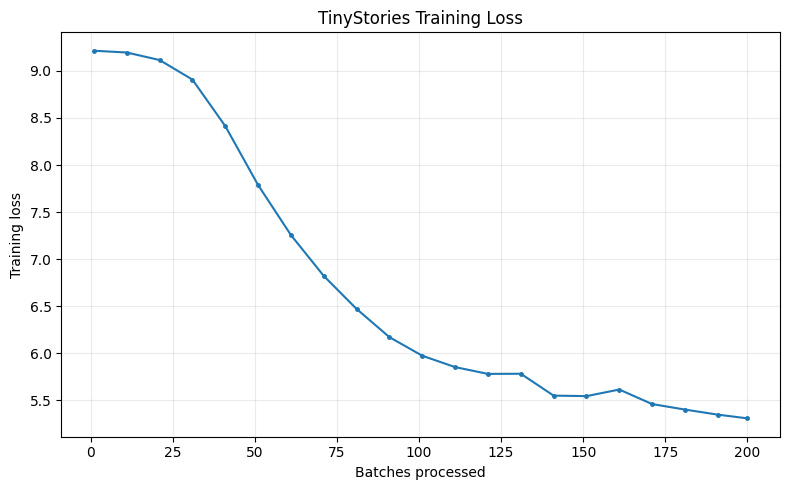

Saved learning curve to: /content/tinystories_training_curve.png
Observed loss change: 9.2141 -> 5.3093


In [ ]:
# Learning curve: loss on the y-axis, batches processed on the x-axis.
import matplotlib.pyplot as plt
from pathlib import Path

assert len(losses) >= 2 and len(steps_seen) == len(losses), (
    "Training did not produce enough loss values to make the required learning curve."
)

plt.figure(figsize=(8, 5))
plt.plot(steps_seen, losses, linewidth=1.5, marker="o", markersize=2.5)
plt.xlabel("Batches processed")
plt.ylabel("Training loss")
plt.title("TinyStories Training Loss")
plt.grid(alpha=0.25)
plt.tight_layout()

plot_path = Path("/content/tinystories_training_curve.png")
plt.savefig(plot_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved learning curve to: {plot_path}")
print(f"Observed loss change: {losses[0]:.4f} -> {losses[-1]:.4f}")
